**Distributions of MD run results and statistical testing**

In [1]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.integrate as integrate

from scipy.spatial.transform import Rotation as R
from matplotlib.transforms import ScaledTranslation

In [2]:
# target and tolerance
nodes_fname = "D4-8_nodes.txt"

N = 10

d_max_mean = 10
d_max_pairs = 2.5

designs = []
labels = []

labels.append("Target")

plt.rcParams["font.sans-serif"] = ['Arial']

In [3]:
names = []

for i in range(1, N+1):
    oxdna_fname = "D4_am_mean_{}.conf".format(i)
    pairs_fname = "D4_am_pairs.txt"
    oxdna_h_inds = {0: list(range(4548, 5657+1))[::-1],
                    1: list(range(3331, 4547+1)),
                    2: list(range(2110, 3330+1))[::-1],
                    3: list(range(1000, 2109+1)),
                    4: list(range(0, 999+1))[::-1],
                    5: list(range(5658, 6648+1))}
    designs.append([oxdna_fname, pairs_fname, oxdna_h_inds])
    labels.append("AutoMod Run {}".format(i))
    
names.append("AutoMod")

for i in range(1, N+1):
    oxdna_fname = "D4_mdna_mean_{}.conf".format(i)
    pairs_fname = "D4_mdna_pairs.txt"
    oxdna_h_inds = {0: list(range(129, 1205+1)),
                    1: list(range(0, 128+1))[::-1] + list(range(5457, 6511+1))[::-1],
                    2: list(range(4277, 5456+1)),
                    3: list(range(3197, 4276+1))[::-1],
                    4: list(range(2198, 3196+1)),
                    5: list(range(1206, 2197+1))[::-1]}
    designs.append([oxdna_fname, pairs_fname, oxdna_h_inds])
    labels.append("MagicDNA Run {}".format(i))
    
names.append("MagicDNA")

for i in range(1, N+1):
    oxdna_fname = "D8_am_mean_{}.conf".format(i)
    pairs_fname = "D8_am_pairs.txt"
    oxdna_h_inds = {0: list(range(12415, 13321+1))[::-1],
                    1: list(range(11371, 12414+1)),
                    2: list(range(10205, 11370+1))[::-1],
                    3: list(range(8897, 10204+1)),
                    4: list(range(7587, 8896+1))[::-1],
                    5: list(range(3922, 5097+1)),
                    6: list(range(2878, 3921+1))[::-1],
                    7: list(range(0, 910+1)),
                    8: list(range(911, 1823+1))[::-1],
                    9: list(range(1824, 2877+1)),
                    10: list(range(5098, 6273+1))[::-1],
                    11: list(range(6274, 7586+1))}
    designs.append([oxdna_fname, pairs_fname, oxdna_h_inds])
    labels.append("AutoMod Run {}".format(i))
    
names.append("AutoMod")

for i in range(1, N+1):
    oxdna_fname = "D8_mdna_mean_{}.conf".format(i)
    pairs_fname = "D8_mdna_pairs.txt"
    oxdna_h_inds = {0: list(range(7415, 8328+1)),
                    1: list(range(8329, 9340+1))[::-1],
                    2: list(range(9341, 10462+1)),
                    3: list(range(10463, 11682+1))[::-1],
                    4: list(range(11683, 12776+1)) + list(range(0, 127+1)),
                    5: list(range(2468, 3575+1))[::-1],
                    6: list(range(3576, 4584+1)),
                    7: list(range(6511, 7414+1))[::-1],
                    8: list(range(5595, 6510+1)),
                    9: list(range(4585, 5594+1))[::-1],
                    10: list(range(1349, 2467+1)),
                    11: list(range(128, 1348+1))[::-1]}
    designs.append([oxdna_fname, pairs_fname, oxdna_h_inds])
    labels.append("MagicDNA Run {}".format(i))
    
names.append("MagicDNA")


In [4]:
def read_nucleotide_positions(fname1, fname2, nucleotides):
    pos = np.zeros((len(nucleotides), 3))
    pairs = {}
    n_pairs = 0
    with open(fname2, 'r') as file2:
        pairs_lines = file2.readlines()
        for pairs_line in pairs_lines:
            try:
                inds = pairs_line.split(" ")
                pairs[int(inds[0])] = int(inds[1])
                pairs[int(inds[1])] = int(inds[0])
            except:
                pass
    with open(fname1, 'r') as file1:
        lines = file1.readlines()
        for i, nucleotide in enumerate(nucleotides):
            line = lines[nucleotide + 3]
            line_content = line.split(" ")
            pos[i, :] = line_content[0:3]
            try:
                pair = pairs[nucleotide]
                pair_line = lines[pair + 3]
                pair_line_content = pair_line.split(" ")
                d = np.sqrt((pos[i, 0] - float(pair_line_content[0]))**2 + (pos[i, 1] - float(pair_line_content[1]))**2 + (pos[i, 2] - float(pair_line_content[2]))**2)
                n_pairs += 1
                if d*0.8518 <= d_max_pairs:
                    pos[i, 0] = (pos[i, 0] + float(pair_line_content[0])) / 2
                    pos[i, 1] = (pos[i, 1] + float(pair_line_content[1])) / 2
                    pos[i, 2] = (pos[i, 2] + float(pair_line_content[2])) / 2
            except KeyError:
                # print('No pair found for {:}.'.format(nucleotide))
                pass
    pos = 0.8518 * pos  # from simulation units to nm
    return pos, n_pairs


def solve_splines(x, y):
    count = len(x)
    a = np.copy(y)
    b = np.zeros(count - 1)
    d = np.zeros(count - 1)
    h = np.zeros(count - 1)
    alpha = np.zeros(count - 1)
    for i in range(0, count - 1):
        h[i] = x[i + 1] - x[i]
    for i in range(1, count - 1):
        alpha[i] = (3 / h[i]) * (a[i + 1] - a[i]) - (3 / h[i - 1]) * (a[i] - a[i - 1])
    c = np.zeros(count)
    l = np.zeros(count)
    l[0] = 1
    mu = np.zeros(count)
    z = np.zeros(count)
    for i in range(1, count - 1):
        l[i] = 2 * (x[i + 1] - x[i - 1]) - h[i - 1] * mu[i - 1]
        mu[i] = h[i] / l[i]
        z[i] = (alpha[i] - h[i - 1] * z[i - 1]) / l[i]
    l[count - 1] = 1
    for j in range(count - 2, -1, -1):
        c[j] = z[j] - mu[j] * c[j + 1]
        b[j] = (a[j + 1] - a[j]) / h[j] - (h[j] * (c[j + 1] + 2 * c[j])) / 3
        d[j] = (c[j + 1] - c[j]) / (3 * h[j])
    return np.stack((a[0:count - 1], b[0:count - 1], c[0:count - 1], d[0:count - 1], x[0:count - 1]))


def spline_point(t_p, P_x, P_y, P_z, t):
    for i in range(len(P_x[0, :])):
        if P_x[4, i] <= t_p <= t[i+1]:
            x = P_x[0, i] + P_x[1, i]*(t_p - P_x[4, i]) + P_x[2, i]*(t_p - P_x[4, i])**2 + P_x[3, i]*(t_p - P_x[4, i])**3
            y = P_y[0, i] + P_y[1, i]*(t_p - P_y[4, i]) + P_y[2, i]*(t_p - P_y[4, i])**2 + P_y[3, i]*(t_p - P_y[4, i])**3
            z = P_z[0, i] + P_z[1, i]*(t_p - P_z[4, i]) + P_z[2, i]*(t_p - P_z[4, i])**2 + P_z[3, i]*(t_p - P_z[4, i])**3
            return np.array([x, y, z])


def spline_derivative(t_p, P_x, P_y, P_z, t):
    for i in range(len(P_x[0, :])):
        if P_x[4, i] <= t_p <= t[i+1]:
            x = P_x[1, i] + 2*P_x[2, i]*(t_p - P_x[4, i]) + 3*P_x[3, i]*(t_p - P_x[4, i])**2
            y = P_y[1, i] + 2*P_y[2, i]*(t_p - P_y[4, i]) + 3*P_y[3, i]*(t_p - P_y[4, i])**2
            z = P_z[1, i] + 2*P_z[2, i]*(t_p - P_z[4, i]) + 3*P_z[3, i]*(t_p - P_z[4, i])**2
            return np.sqrt(x**2 + y**2 + z**2)

        
def construct_splines(nodes):
    splines = {}
    for h, node_array in nodes.items():
        t = np.linspace(0, 1, node_array.shape[0])
        Px = solve_splines(t, node_array[:, 0])
        Py = solve_splines(t, node_array[:, 1])
        Pz = solve_splines(t, node_array[:, 2])
        splines[h] = [t, Px, Py, Pz]
    return splines


def read_nodes(fname):
    nodes = []
    nodes_arrays = {}
    with open(fname, 'r') as file:
        lines = file.readlines()
        for line in lines:
            coords = line.split(",")
            if len(coords) == 3:
                nodes.append(np.array([float(coords[0]), float(coords[1]), float(coords[2])]))
    node_pos = np.zeros((len(nodes), 3))
    for i in range(len(nodes)):
        node_pos[i, :] = nodes[i]
    nodes_arrays[0] = node_pos
    return nodes_arrays          


def sample_from_splines_uniformly(splines, min_l):
    pos_dct = {}
    for h, spline_lst in splines.items():
        t = spline_lst[0]
        Px = spline_lst[1]
        Py = spline_lst[2]
        Pz = spline_lst[3]
        array = np.zeros((min_l, 3))
        l_tot, _ = integrate.quad(spline_derivative, 0, 1, args=(Px, Py, Pz, t), limit=150)
        count = 0
        for i in range(1, len(t)):
            l_seg, _ = integrate.quad(spline_derivative, t[i-1], t[i], args=(Px, Py, Pz, t))
            n_points = int(np.round((l_seg / l_tot) * min_l))
            if i == len(t)-1 and n_points + count < min_l:
                n_points += min_l - n_points - count
            t_p = np.linspace(t[i-1], t[i], n_points, endpoint=False)
            for j in range(n_points):
                if count + j < min_l:
                    array[count + j, :] = spline_point(t_p[j], Px, Py, Pz, t)
            count += n_points
        pos_dct[h] = array
    return pos_dct 


def get_oxdna(ind_dct, fname1, fname2):
    pos_dct = {}
    pair_counts = {}
    min_l = 100000
    for h_num, ind_list in ind_dct.items():
        pos_dct[h_num], pair_counts[h_num] = read_nucleotide_positions(fname1, fname2, ind_list)
        if pos_dct[h_num].shape[0] < min_l:
            min_l = pos_dct[h_num].shape[0]
    mean_pos = np.zeros((1, 3))
    for h_num, pos in pos_dct.items():
        if pos.shape[0] > min_l:
            pos_dct[h_num] = pos[np.linspace(0, pos.shape[0]-1, min_l, dtype=np.int32), :]
        mean_pos += np.sum(pos_dct[h_num], axis=0) * (1/min_l)
    mean_pos = mean_pos / len(pos_dct)
    for h_num, pos in pos_dct.items():
        pos_dct[h_num] = pos - mean_pos
    return pos_dct, min_l, pair_counts


def get_target(fname, min_l):
    nodes = read_nodes(fname)
    splines = construct_splines(nodes)
    pos_dct = sample_from_splines_uniformly(splines, min_l)
    mean_pos = np.zeros((1, 3))
    for h_num, pos in pos_dct.items():
        mean_pos += np.sum(pos_dct[h_num], axis=0) * (1/min_l)
    mean_pos = mean_pos / len(pos_dct)
    for h_num, pos in pos_dct.items():
        pos_dct[h_num] = pos - mean_pos
    return pos_dct


def align_b_to_a(a, b):
    rot, rssd, sens = R.align_vectors(a, b, return_sensitivity=True)
    rot.as_matrix()
    new_b = rot.apply(b)
    return rot, new_b, rssd

In [5]:
positions = []
for design in designs:
    oxdna_pos, min_l, pair_counts = get_oxdna(design[2], design[0], design[1])
    target_pos = get_target(nodes_fname, min_l)
    positions.append([oxdna_pos, min_l, target_pos])

In [6]:
# comparison of means
mean_results = []
alignments = []
for position in positions:
    
    oxdna_mean = np.zeros((position[1], 3))
    for h, pos in position[0].items():
        oxdna_mean = np.add(oxdna_mean, pos)
    oxdna_mean = oxdna_mean / len(position[0])

    target_mean = np.zeros((position[1], 3))
    for h, pos in position[2].items():
        target_mean = np.add(target_mean, pos)
    target_mean = target_mean / len(position[2])

    rot_mat, new_pos, rssd = align_b_to_a(target_mean, oxdna_mean)
    alignments.append(rot_mat)
    # print("Total RSSD is {} nm.".format(rssd))
    correct = 0
    green_pos = []
    red_pos = []
    d_vals_in = []
    d_vals_out = []
    for i in range(position[1]):
        d = np.sqrt(np.sum(np.square(new_pos[i, :] - target_mean[i, :])))
        if d <= d_max_mean:
            correct += 1
            green_pos.append(new_pos[i, :])
            d_vals_in.append(d)
        else:
            red_pos.append(new_pos[i, :])
            d_vals_out.append(d)
    acc = 100*correct/position[1]
    # print("Total accuracy is {}/{} = {}%.".format(correct, position[1], acc))

    greens = np.asarray(green_pos)
    reds = np.asarray(red_pos)
    mean_results.append([greens, reds, np.sqrt(rssd**2/position[1]), acc, d_vals_in, d_vals_out, new_pos])

In [7]:
# compute mean RMSD, variance and std
mus = []
sigmas = []

for i in range(len(mean_results) // N):
    mu = 0
    for j in range(i*N+1, (i+1)*N+1):
        mu += mean_results[j-1][2]
    mu = mu / N
    sigma = 0
    for j in range(i*N+1, (i+1)*N+1):
        sigma += (mean_results[j-1][2] - mu) ** 2
    sigma = sigma / N
    mus.append(mu)
    sigmas.append(sigma)
    
    print(names[i])
    print("Mean RMSD is: {} nm.\nVariance for RMSD is: {} nm².".format(mu, sigma))
    print("Standard deviation: {} nm.\n\n".format(np.sqrt(sigma)))

AutoMod
Mean RMSD is: 33.241824599949986 nm.
Variance for RMSD is: 7.537590211888613 nm².
Standard deviation: 2.745467211949291 nm.


MagicDNA
Mean RMSD is: 54.43970791838278 nm.
Variance for RMSD is: 23.71177785920917 nm².
Standard deviation: 4.869474084458112 nm.


AutoMod
Mean RMSD is: 15.996063745166145 nm.
Variance for RMSD is: 21.304684160995215 nm².
Standard deviation: 4.615699747708382 nm.


MagicDNA
Mean RMSD is: 32.1910843943419 nm.
Variance for RMSD is: 44.25369901975726 nm².
Standard deviation: 6.6523453773655845 nm.




In [8]:
from scipy.stats import ttest_ind

samples = [[], []]
for k, d in enumerate([0, 2]):
    samples[k].append(np.array([mean_results[i][2] for i in range(d*N, (d+1)*N)]))
    print("Welch's t-test:\n")
    sample1 = np.array([mean_results[i][2] for i in range(d*N, (d+1)*N)])
    sample2 = np.array([mean_results[j][2] for j in range((d+1)*N, (d+2)*N)])
    samples[k].append(sample2)

    result = ttest_ind(sample1, sample2, equal_var=False, alternative='less')
    print(names[k*2] + " against " + names[k*2+1])
    print("p =", result.pvalue, "\n")

Welch's t-test:

AutoMod against MagicDNA
p = 7.998065552286132e-09 

Welch's t-test:

AutoMod against MagicDNA
p = 9.166805158223236e-06 



<IPython.core.display.Javascript object>


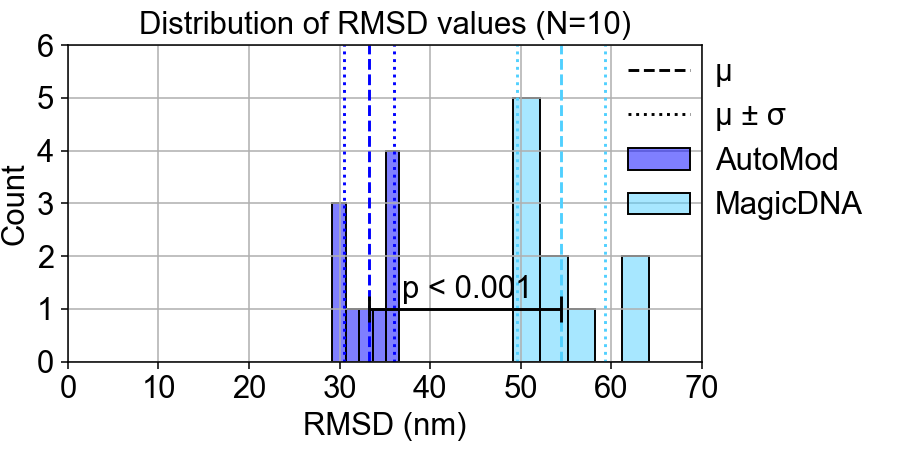

<IPython.core.display.Javascript object>


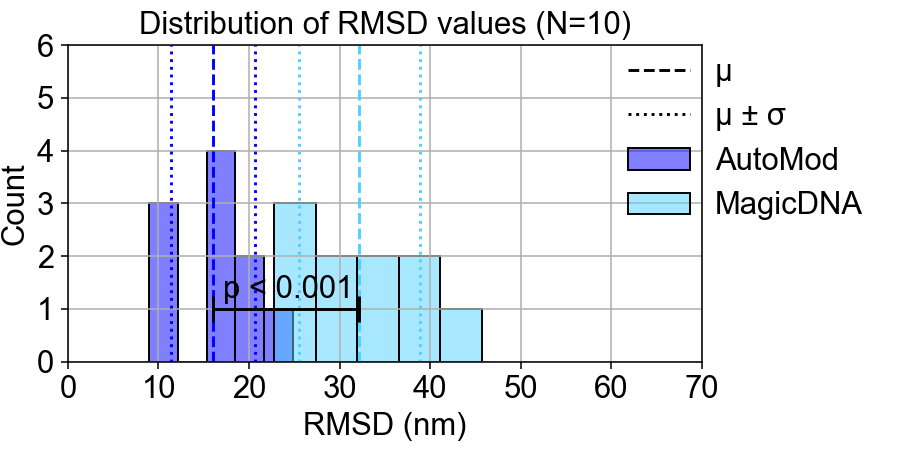

In [9]:
cm = (1/2.54)
font = 16

cols = [[0, 0, 1, 0.5],
        [80/255, 208/255, 1, 0.5],
        [160/255, 32/255, 1, 0.5],
        [1, 96/255, 208/255, 0.5],
        [1, 0, 0, 0.5]];

for k, d in enumerate([0, 2]):
    f = plt.figure(figsize=(16.5*cm, 0.5*16.5*cm))
    ax = f.add_subplot(1, 1, 1, position=[0.075, 0.2, 0.7, 0.7])
    ax.grid()
    for i in range(2):
        if i == 0:
            plt.vlines(-5, ymin=0, ymax=6, color="black", ls='--', label='\N{GREEK SMALL LETTER MU}');
            plt.vlines(-5, ymin=0, ymax=6, color="black", ls='dotted', label='\N{GREEK SMALL LETTER MU} \N{PLUS-MINUS SIGN} \N{GREEK SMALL LETTER SIGMA}');
    
        ax.hist(samples[k][i], bins=5, color=cols[i], label=names[k*2+i], edgecolor='black');
        plt.vlines(mus[k*2+i], ymin=0, ymax=6, color=cols[i][0:3]+[1], ls='--');
        plt.vlines([mus[k*2+i]-np.sqrt(sigmas[k*2+i]), mus[k*2+i]+np.sqrt(sigmas[k*2+i])], ymin=0, ymax=6, color=cols[i][0:3]+[1], ls='dotted');

    ax.set_xlabel("RMSD (nm)", fontsize=font); ax.set_ylabel("Count", fontsize=font);
    ax.set_xticks([10*i for i in range(0,8)], labels=[10*i for i in range(0,8)], fontsize=font);
    ax.set_yticks([i for i in range(7)], labels=[i for i in range(7)], fontsize=font);
    plt.ylim(0, 6); plt.xlim(0, 70);
    plt.title("Distribution of RMSD values (N={})".format(N), fontsize=font);
    plt.hlines(1, mus[k*2], mus[k*2+1], colors='black', linestyles='solid');
    plt.vlines([mus[k*2], mus[k*2+1]], 0.75, 1.25, colors='black', linestyles='solid');
    plt.annotate('p < 0.001', ((mus[k*2]+mus[k*2+1])/2 - 7, 1.2), fontsize=font);
    if d == 0:
        n = 4
    else:
        n = 8
    f.legend(loc=(0.68, 0.485), fontsize=font, frameon=False);
    f.savefig("D{}_histogram.png".format(n), dpi=900, transparent=True)